In [ ]:
!pip install gensim nltk

In [ ]:
import nltk
from gensim.models import FastText
from nltk.tokenize import word_tokenize, sent_tokenize

In [ ]:
# Download necessary NLTK data (if not already done)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('brown') # A standard NLTK corpus

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!


True

In [ ]:
from nltk.corpus import brown

sentences = []
for sent in brown.sents():
    sentences.append([word.lower() for word in sent])
print(len(sentences))

print(sentences[0])

57340
['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', "atlanta's", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that', 'any', 'irregularities', 'took', 'place', '.']


In [ ]:
from gensim.models import Phrases

bigram_transformer = Phrases(sentences, min_count=1)

phrased_sentences = list(bigram_transformer[sentences])
print(phrased_sentences[0])

['the', 'fulton_county', 'grand_jury', 'said_friday', 'an_investigation', 'of', "atlanta's", 'recent', 'primary_election', 'produced', '``', 'no_evidence', "''", 'that', 'any', 'irregularities', 'took_place', '.']


In [ ]:
model = FastText(phrased_sentences, vector_size=100, window=7, min_count=3, epochs=50)

I am choosing FastText over Word2Vec because it handles OOV words better. Word2Vec cannot process OOV words at all, whilst FastText breaks down words into subwords, which allows it to decompose unknown words and generate reasonable embeddings for them. For example, if Word2Vec sees the word "apple" in the corpus, it won't know how to compare "apples" unless "apples" was also in the corpus. FastText breaks down words into subwords which is vital in english due to prefix, suffix, and general word composition. The words "book" and "store" can be combined to "bookstore." Furthermore, it can learn how words can be plural, like "bookstores." Word2Vec treats these all as separate words. FastText allows us to learn actual subwords and compose new words OOV.

In [ ]:
model.save("fasttext_brown.model")

In [ ]:
similar_words = model.wv.most_similar('money', topn=5)
print(f"Words similar to 'money': {similar_words}")

similar_words = model.wv.most_similar('grand_jury', topn=5)
print(f"Words similar to 'grand_jury': {similar_words}")

similar_words = model.wv.most_similar('money_machine', topn=5)
print(f"Words similar to 'money_machine': {similar_words}")


Words similar to 'money': [('monei', 0.8831857442855835), ('monet', 0.7866047024726868), ('enough_money', 0.7204798460006714), ('rooney', 0.7133353352546692), ('honey', 0.7040287256240845)]
Words similar to 'grand_jury': [('grand', 0.7305682301521301), ('grandma', 0.7228730320930481), ('jury', 0.7199320197105408), ('grandeur', 0.7198553085327148), ('grand_champion', 0.7147985100746155)]
Words similar to 'money_machine': [('machine', 0.8562146425247192), ('machine_gun', 0.8513646721839905), ('machine_quack', 0.8449570536613464), ('machine_tool', 0.835391104221344), ('machinery', 0.8215333223342896)]


In [ ]:
import numpy as np

money_wv = model.wv['money']
print(f"Word embedding for 'money': {money_wv}")
print(f"Norm: {np.linalg.norm(money_wv)}")

Word embedding for 'money': [-0.46510962 -3.4468422   0.5905056  -2.8504255  -0.09903577 -1.3903298
  1.4403691  -1.6879753   2.355663    0.01723493 -0.35724965  2.2879868
 -1.9950912  -0.8504131  -0.9376169  -1.9026185  -0.5111398   2.53057
  4.426491   -0.49236667 -1.4171947   0.90758824  0.3531013   0.6264398
  2.3786154  -1.9062374  -0.5630657   2.1955144   0.14320092 -0.9245206
 -0.99472433  0.5347952   1.6793314  -0.62350345 -1.466156   -3.007701
 -4.2544637   0.62968224  0.32701573 -0.12758179  2.5101094   1.3539914
  5.254448   -2.710715    1.3552097   2.4790423  -0.62526184 -0.96700925
  3.097408    4.2510676   0.9079426   1.3981633  -0.2048765  -0.9625617
  0.65638196 -0.14181544  3.7236588  -0.64708114  4.915274    1.7526447
  1.3175237  -0.08006185 -0.5427621  -2.8924708  -0.61212176 -2.3708556
  0.67566454  3.082215   -3.1926482  -0.83815295  0.63689464  0.703516
  1.0663493   1.3236974   0.36845753 -0.4484603  -0.72899973 -0.3618684
  1.1617738   2.7869332  -0.25195977 -0

In [ ]:
def cosine_sim_batch(word_pairs):

  word1s = [word_pair[0] for word_pair in word_pairs]
  word2s = [word_pair[1] for word_pair in word_pairs]

  wv1 = model.wv[word1s]
  wv2 = model.wv[word2s]

  return np.sum(wv1 * wv2, axis=1) / (np.linalg.norm(wv1, axis=1) * np.linalg.norm(wv2, axis=1))

def cosine_sim(word1, word2):

  wv1 = model.wv[word1]
  wv2 = model.wv[word2]

  return np.dot(wv1, wv2) / (np.linalg.norm(wv1) * np.linalg.norm(wv2))

In [ ]:
sim_correct = model.wv.similarity('money', 'gold')
sim_calc = cosine_sim('money', 'gold')
print(f"ACTUAL: {sim_correct} CALC: {sim_calc}")

ACTUAL: 0.16260841488838196 CALC: 0.16260841488838196


In [ ]:
list_of_comps = [
    ('horse', 'hay'),
    ('run', 'walk'),
    ('school', 'university'),
    ('water', 'what'),
    ('eye', 'paint')
]

cosine_sim_batch(list_of_comps)

array([0.41255403, 0.47524226, 0.5385225 , 0.03396826, 0.39429173],
      dtype=float32)

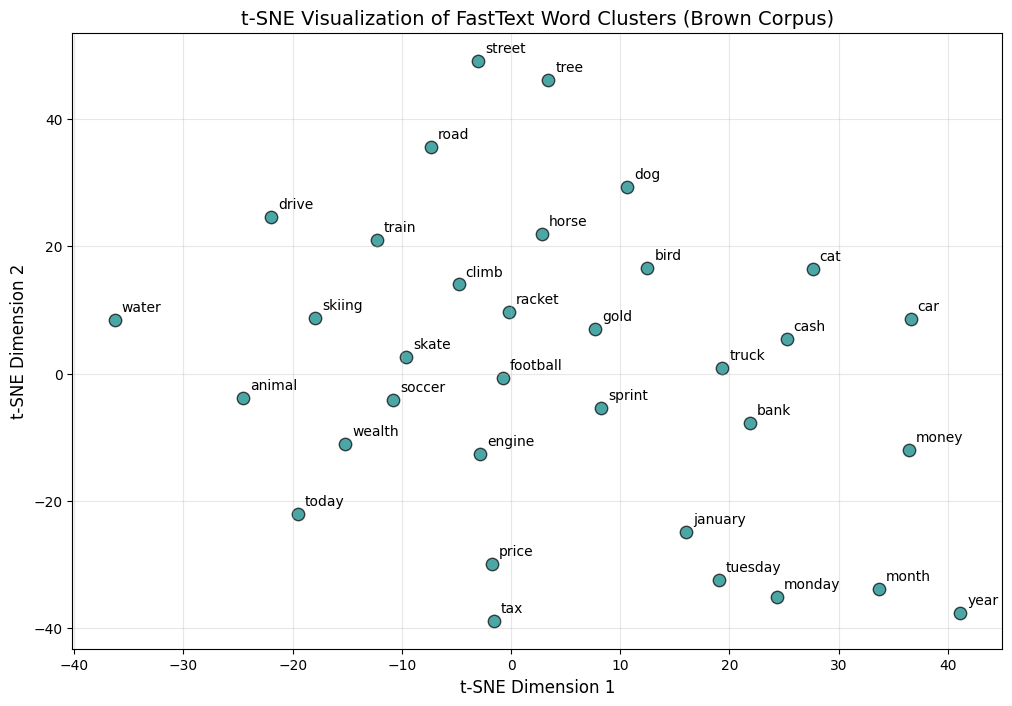

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

words_to_visualize = [
    # Money related
    'money', 'cash', 'bank', 'gold', 'price', 'wealth', 'tax',
    # Animals / outside
    'horse', 'dog', 'cat', 'animal', 'tree', 'water', 'bird',
    # Driving
    'car', 'road', 'truck', 'train', 'drive', 'street', 'engine',
    # Calendar
    'monday', 'tuesday', 'january', 'month', 'year', 'today',
    # Sports
    'football', 'skiing', 'skate', 'soccer', 'racket', 'climb', 'sprint'

]

word_vectors = np.array([model.wv[w] for w in words_to_visualize])

tsne = TSNE(n_components=2, random_state=42, perplexity=8)
vectors_2d = tsne.fit_transform(word_vectors)

plt.figure(figsize=(12, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='teal', edgecolors='k', s=80, alpha=0.7)

for i, word in enumerate(words_to_visualize):
    plt.annotate(word,
                 xy=(vectors_2d[i, 0], vectors_2d[i, 1]),
                 xytext=(5, 4),
                 textcoords='offset points',
                 ha='left',
                 va='bottom',
                 fontsize=10)

plt.title("t-SNE Visualization of FastText Word Clusters (Brown Corpus)", fontsize=14)
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

Cosine similarity is highly important for word embedding spaces because we need metrics to make sense of the word embeddings. What value does a 200-dimension word vector for "apple" have to a human? Not much. Our value is in comparison. We don't entirely care in the end how "apple" is represented, we care about how this representation allows "apple" to be compared to other words. Thus, similarity score enables humans to reason about words and understand the word embedding space. They let us know "apple" is similar to "orange" but not as similar to "car."

Another thing to consider is that cosine similarity only looks at the angle between embeddings and ignores magnitude. If these magnitudes are biased, say towards frequency, cosine similarity stays robust against this.

In [ ]:
def dist_batch(word_pairs):

  word1s = [word_pair[0] for word_pair in word_pairs]
  word2s = [word_pair[1] for word_pair in word_pairs]

  wv1 = model.wv[word1s]
  wv2 = model.wv[word2s]

  return np.linalg.norm(wv1 - wv2, axis=1)

def dist(word1, word2):

  wv1 = model.wv[word1]
  wv2 = model.wv[word2]

  return np.linalg.norm(wv1 - wv2)

In [ ]:
dist_calc = dist('money', 'cash')
print(f"DISTANCE (money and cash): {dist_calc}")

dist_calc = dist('university', 'college')
print(f"DISTANCE (university and college): {dist_calc}")

dist_calc = dist('cat', 'train')
print(f"DISTANCE (cat and train): {dist_calc}")

dist_calc = dist('street', 'year')
print(f"DISTANCE (street and year): {dist_calc}")

DISTANCE (money and cash): 19.042530059814453
DISTANCE (university and college): 15.697528839111328
DISTANCE (cat and train): 19.676910400390625
DISTANCE (street and year): 34.49856948852539


In [ ]:
def compare_words(word1, word2, metric='cosine'):
    if metric == 'cosine':
        return cosine_sim(word1, word2)
    elif metric == 'euclidean':
        return dist(word1, word2)

def compare_words_batch(word_pairs, metric='cosine'):
    if metric == 'cosine':
        return cosine_sim_batch(word_pairs)
    elif metric == 'euclidean':
        return dist_batch(word_pairs)

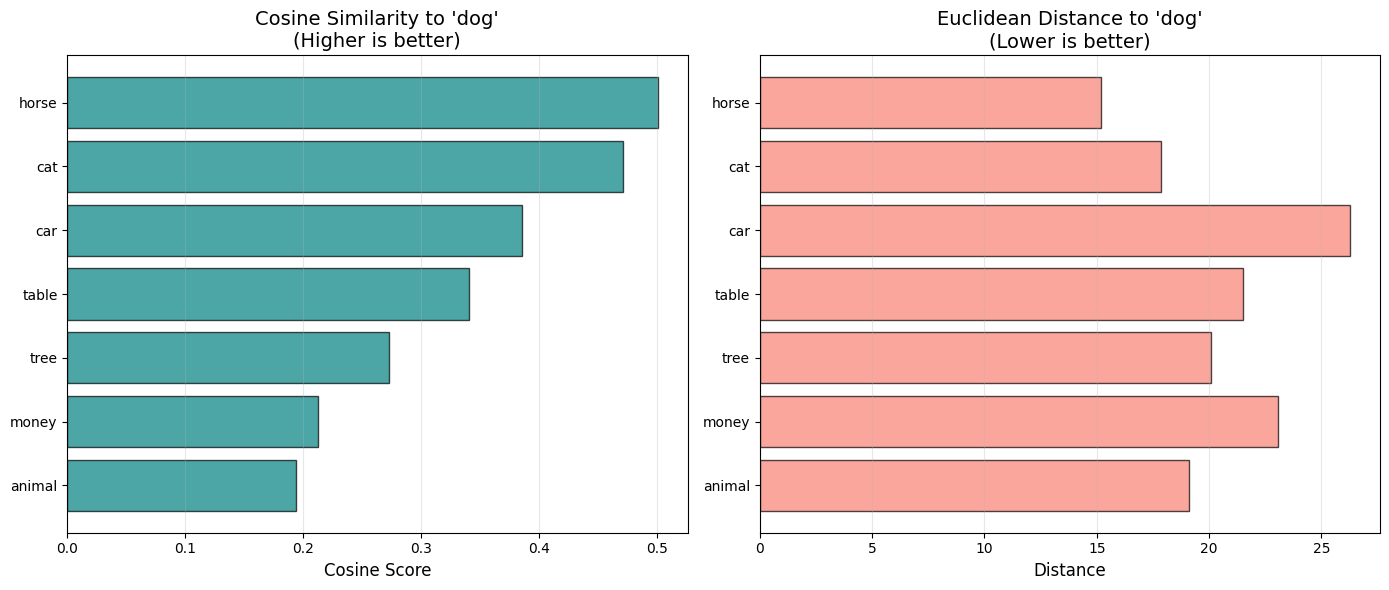

In [ ]:
target_word = 'dog'
comparison_words = ['cat', 'horse', 'animal', 'tree', 'car', 'money', 'table']

# Formulate pairs for the batch function
word_pairs = [(target_word, w) for w in comparison_words]

# Toggle between metrics using your new function parameters
cosine_scores = compare_words_batch(word_pairs, metric='cosine')
euclidean_scores = compare_words_batch(word_pairs, metric='euclidean')

# Sort everything based on Cosine Similarity (Descending)
sorted_indices = np.argsort(cosine_scores)[::-1]
sorted_words = [comparison_words[i] for i in sorted_indices]
sorted_cos = [cosine_scores[i] for i in sorted_indices]
sorted_euc = [euclidean_scores[i] for i in sorted_indices]

# Create the visualization (styled similarly to your old visual)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Cosine Similarity
ax1.barh(sorted_words[::-1], sorted_cos[::-1], color='teal', edgecolor='k', alpha=0.7)
ax1.set_title(f"Cosine Similarity to '{target_word}'\n(Higher is better)", fontsize=14)
ax1.set_xlabel("Cosine Score", fontsize=12)
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: Euclidean Distance
ax2.barh(sorted_words[::-1], sorted_euc[::-1], color='salmon', edgecolor='k', alpha=0.7)
ax2.set_title(f"Euclidean Distance to '{target_word}'\n(Lower is better)", fontsize=14)
ax2.set_xlabel("Distance", fontsize=12)
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

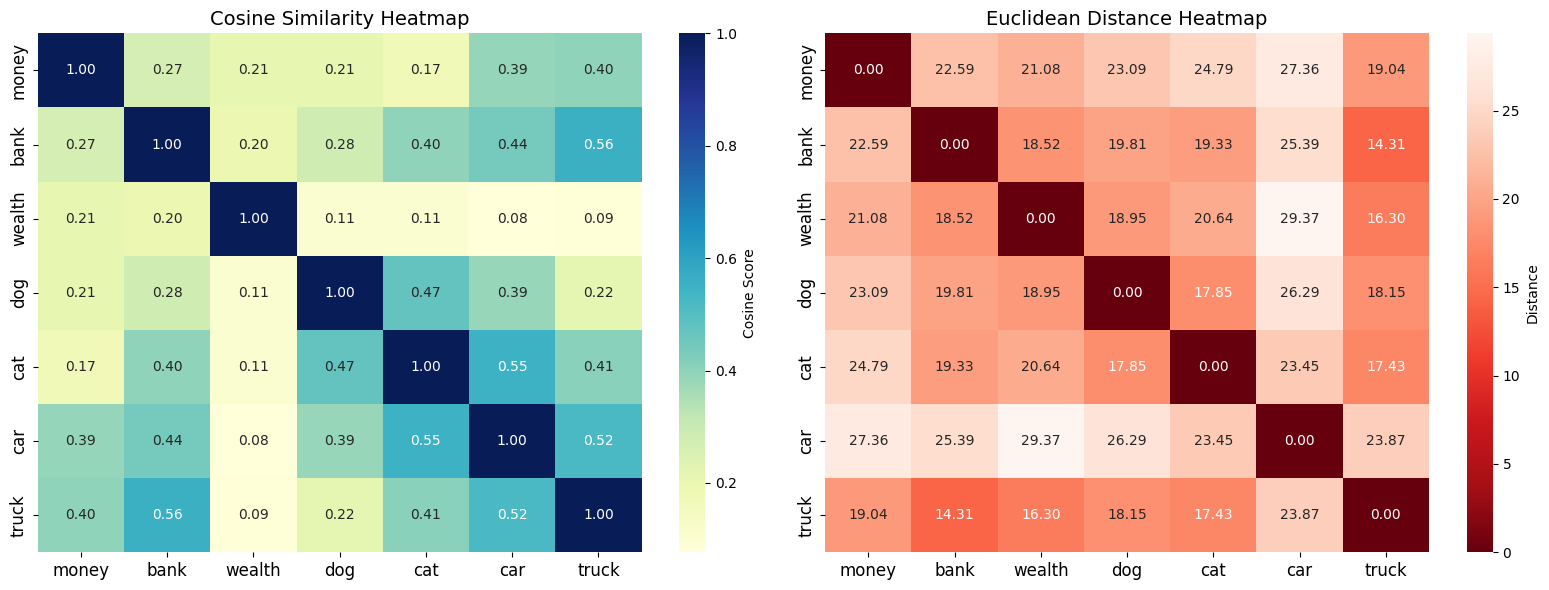

In [ ]:
import seaborn as sns

# A mix of related and unrelated words to show clear contrasts
heatmap_words = ['money', 'bank', 'wealth', 'dog', 'cat', 'car', 'truck']
n = len(heatmap_words)

# Initialize empty matrices
matrix_cos = np.zeros((n, n))
matrix_euc = np.zeros((n, n))

# Fill the matrices with the pairwise scores using your toggle function
for i in range(n):
    for j in range(n):
        matrix_cos[i, j] = compare_words(heatmap_words[i], heatmap_words[j], metric='cosine')
        matrix_euc[i, j] = compare_words(heatmap_words[i], heatmap_words[j], metric='euclidean')

# Create side-by-side heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Cosine Heatmap (Higher = more similar)
sns.heatmap(matrix_cos, xticklabels=heatmap_words, yticklabels=heatmap_words,
            annot=True, cmap='YlGnBu', fmt=".2f", ax=ax1, cbar_kws={'label': 'Cosine Score'})
ax1.set_title("Cosine Similarity Heatmap", fontsize=14)
ax1.tick_params(axis='both', labelsize=12)

# Euclidean Heatmap (Lower = more similar)
# We use reversed Reds (Reds_r) so darker shades still represent "closer" relationships
sns.heatmap(matrix_euc, xticklabels=heatmap_words, yticklabels=heatmap_words,
            annot=True, cmap='Reds_r', fmt=".2f", ax=ax2, cbar_kws={'label': 'Distance'})
ax2.set_title("Euclidean Distance Heatmap", fontsize=14)
ax2.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

Cosine similarity does not capture the magnitude of these word embeddings. As I checked prior, these embeddings are not normalized. Thus, some information is lost with cosine similarity. With Euclidean distance, we capture absolute spatial distances rather than just angular distances. As alluded to before, these magnitudes could be biased, but regardless of that there is information in our embedding space being lost with cosine similarity. If these magnitudes are indeed biased towards word frequency, then Euclidean distance as a dissimilarity metric further captures distances by means of how rare or niche a word is. Arguably, this may be a desired consideration when comparing words, hence why this is an alternate metric.